------------Test 1------------
Testing undamped NR with h = 10.0:
Converged: True, iterations: 15

Testing damped NR with h = 2.0:
Converged: True, iterations: 1, dampening used: 0, backtracks: 0

------------Test 2------------

Performance Comparison:
Method               Steps      NR Iters        Max Local Error
------------------------------------------------------------
Fixed (h=0.01)       2002       6006            N/A            
Adaptive             136        429             9.295e-05      

------------Test 3------------


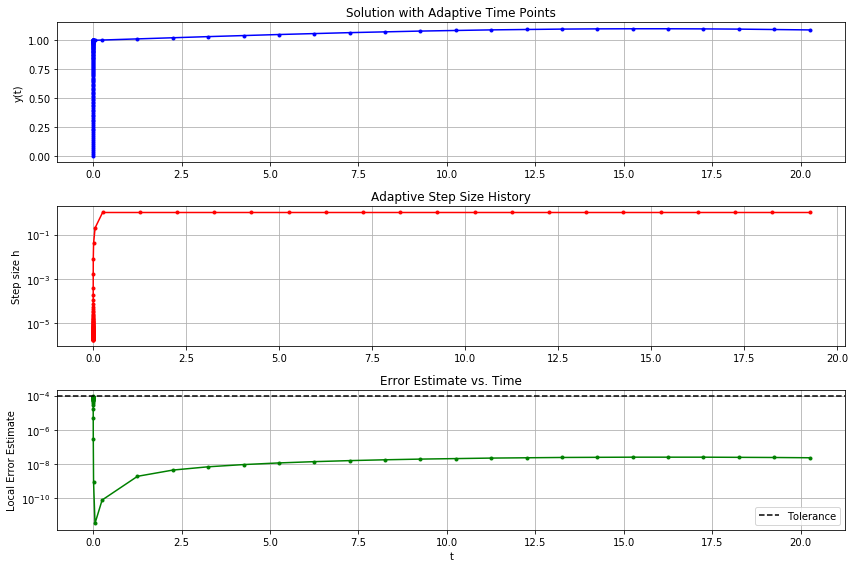

In [21]:
import numpy as np
import matplotlib.pyplot as plt

h_list = [0.01, 0.05, 0.1]
t_start = 0    
t_end = 20
k = 10 ** 4
tol = 1e-4

def f(c, t): #define ODE
    return -k * c + k * (1 + 0.1 *np.sin(0.1 * t))

def euler_forward(h_val, t_start, t_end): #explicit method
    t_values = np.arange(t_start, t_end + h_val, h_val)
    c_values = np.zeros(len(t_values))
    c_values[0] = 0 #initial values

    for i in range(1, len(t_values)):
        c_n = c_values[i - 1]
        c_values[i] = c_n + h_val * f(c_n, t_values[i - 1])
    return t_values, c_values

def euler_backward_newton(f, t_start, t_end, h_val, tol = 1e-6, max_iteration = 15): #implicit method
    t_values = np.arange(t_start, t_end + h_val, h_val)
    y_values = np.zeros_like(t_values)
    y_values[0] = 0
    iteration_counts = []
    
    for j in range(1, len(t_values)):
        t_next = t_values[j]
        y_prev = y_values[j - 1]
        y_guess = y_prev + h_val * f(y_prev, t_values[j - 1]) #first guess using forward method
        converge = False

        for z in range(max_iteration):
            g = y_guess - y_prev - h_val * f(y_guess, t_next)         #residual function

            g_prime = 1 + h_val * k
            y_next = y_guess - (g / g_prime) #update newton-ralphson
            
            if abs(y_next - y_guess) < tol: #check if converges
                converge = True
                iteration_counts.append(z + 1)
                y_guess = y_next
                break
            y_guess = y_next
            
        if converge is False: 
            print(f'Newton did not converge at t = {t_next}')
            iteration_counts.append(max_iteration)
        y_values[j] = y_guess #store solutions
            
    return t_values, y_values, iteration_counts

def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n
    backtracks = 0 
    dampening = 0
    
    for ki in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h) 
        
        if abs(g) < tol: #check if converges
            return y_guess, ki, True, dampening, backtracks
        
        g_prime = g_prime_func(y_guess, y_n, t_next, h)
        delta = -g / g_prime
        
        alpha = 1.0 #start line search with full step
        g_current = abs(g)
        
        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            if g_new < g_current:  # Sufficient decrease
                break
            
            alpha = alpha / 2.0 #step size decreases
            
            dampening = True
            backtracks += 1
            
            if alpha < alpha_min: #stop if step size too small
                print(f"Warning: alpha too small at iter {ki}")
                return y_guess, ki, False, dampening, backtracks
        
        y_guess = y_new
    
    return y_guess, max_iter, False, dampening, backtracks

def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    y_full, iters_full, result_full, damp_full, back_full = nr_solver(y_n, t_n + h, h)  # Single step of size h
    if result_full is False: 
        return None, None, None, iters_full, False
    
    y_half_1, iters_1, result_1, damp_1, back_1 = nr_solver(y_n, t_n + h/2, h/2)     # Two half-steps of size h/2
    if result_1 is False:
        return None, None, None, iters_full + iters_1, False
    
    y_half, iters_2, result_2, damp_2, back_2 = nr_solver(y_half_1, t_n + h, h/2)
    if result_2 is False:
        return None, None, None, iters_full + iters_1 + iters_2, False
    
    error = abs(y_half - y_full) #local error evaluation
    total_iters = iters_full + iters_1 + iters_2 # Total NR iterations for this error estimate
    
    return y_full, y_half, error, total_iters, True


def adaptive_step(y_n, t_n, h, tol, nr_solver, h_min=1e-6, h_max=1.0, safety=0.9):

    y_full, y_half, error, iters, work = estimate_error_step_doubling(y_n, t_n, h, nr_solver)     # Try the step with error estimation
    
    if not work: #chat gpt helped me with adjusting the steps if the estimation fails
        return y_n, h, 0.5* h, False, iters, None
    
    if error < 1e-14:  # Compute new step size suggestion
        h_new = min(2.0 * h, h_max)
    else:
        h_new = h * np.sqrt(tol / error)
        h_new = safety * h_new  # Safety factor
        h_new = max(h_min, min(h_max, h_new))
        
    h_new = max(0.2 * h, min(5.0 * h, h_new))   
    h_new = max(1e-6, h_new) #chatgpt helped me troubleshoot because my code kept on crashing while running due to too low of a h
    
    if error < tol:
        return y_half, h, h_new, True, iters, error # ACCEPT: use the more accurate two-half-step result
    else:
        return y_n, h, h_new, False, iters, error         # REJECT: don't update y, suggest smaller h
    
def g_(y, y_n, t_next, h): #residual formula for implicit method
    return (y - y_n) - (h * f(y, t_next))
    
def dg_dy(y, y_n, t_next, h):
    return 1 + h * k

def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol):
    
    # Initialize
    t_values = [t0]
    y_values = [y0]
    h = h0
    h_history = []
    error_history = []

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used': 0,
        'function_evals': 0
    }
    
    def nr_solve(y_n, t_next, h):
        return damped_newton_raphson(y_n, t_next, h, g_, dg_dy)
    
    t = t0
    y = y0    
    # Main loop
    while t < t_final:
        y_new, h_old, h_new, accepted, iteration, error = adaptive_step(y, t, h, tol, nr_solve)
        
        stats['nr_iterations'].append(iteration)
        
        if accepted is True:
            t += h
            y = y_new
            
            t_values.append(t)
            y_values.append(y)
            h_history.append(h)
            error_history.append(error)
            
            stats['accepted_steps'] += 1
        
        else:
            stats['rejected_steps'] += 1
            if h <= 1e-6:
                print("Stopped: h reached minimum step size and step was still rejected")
                break
        
        h = h_new
    
    return np.array(t_values), np.array(y_values), h_history, error_history, stats

print('------------Test 1------------')

h_large = 2

def basic_newton_raphson(y_n, t_next, h, tol = 1e-6, max_iteration = 15):
    y = y_n
    
    for d in range(max_iteration):
        g_val = g_(y, y_n, t_next, h)
        
        if abs(g_val) < tol:
            return y, max_iteration, True
            
        g_prime = dg_dy(y, y_n, t_next, h)
        y = y - (g_val / g_prime)
        
    return y, max_iteration, False

print("Testing undamped NR with h = 2.0:") #compare damp and undamp
try:
    y_undamped, iters, success = basic_newton_raphson(0, h_large, h_large)
    print(f"Converged: {success}, iterations: {iters}")
except:
    print("Failed to converge!")

print("\nTesting damped NR with h = 2.0:")
y_damped, iters, success, damps, bt = damped_newton_raphson(0, h_large, h_large, g_, dg_dy)
print(f"Converged: {success}, iterations: {iters}, dampening used: {damps}, backtracks: {bt}")

print('\n------------Test 2------------')

t_fixed, y_fixed, ic =euler_backward_newton(f, t_start, t_end, 0.01) # Fixed step size (baseline)
t_adapt, y_adapt, h_hist, error_history, stats = adaptive_implicit_euler(f, 0, t_start, t_end, 0.1, tol=1e-4) # Adaptive step size (same target accuracy)

print("\nPerformance Comparison:")
print(f"{'Method':<20} {'Steps':<10} {'NR Iters':<15} {'Max Local Error':<15}")
print("-" * 60)
print(f"{'Fixed (h=0.01)':<20} {len(t_fixed):<10} {len(t_fixed)*3:<15} {'N/A':<15}")
print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {sum(stats['nr_iterations']):<15} {max(error_history):<15.3e}")

print('\n------------Test 3------------')
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, 'b-o', markersize=3)
plt.ylabel('y(t)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)

plt.subplot(3, 1, 3)
# Plot error estimate
plt.semilogy(t_adapt[1:], error_history, 'g-o', markersize=3)
plt.axhline(y=tol, color='k', linestyle='--', label='Tolerance')
plt.ylabel('Local Error Estimate')
plt.xlabel('t')
plt.title('Error Estimate vs. Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
'''''
In part two I simulated a chemical reaction with fast kinetics. It was stiff due to the fast reaction rate and the slowly 
varying equilibrium. The first method I tried was the Forward method. It was very unstable and unreliable. Then I tried the 
Backward method which maintained stability for larger step sizes and did not require many iterations. This displayed how 
implicit methods are more efficient than explicit methods for stiff systems. Newton-Raphson is a method where an equation is 
solved by repeatedly improving a guess. Each step gets closer to the correct answer using the slope. When everything works out, 
this method can be fast and accurate. However, there are times when the guess overshoots the exact answer; particularly with 
really large step sizes. To account for this, damping is used. This is when the step size is scaled down. If the step does not 
reduce the error, then it is cut in half again. The steps continue to get reduced until the guess improves. For this simulation,
both the undamped and damped methods converged due to the ODE being linear. Linear equations are naturally good for the 
Newton-Raphson method so damping was not required. Despite this, damping is still useful and can succeed when the undamped 
method fails. Damping methods are especially useful for nonlinear systems. Adaptive step sizes reduce computation cost. Due to 
this, they are beneficial for varying and stiff systems. One thing I learned is how to change the algorithm for implicit methods
utilizing damping for more stable results.

''''